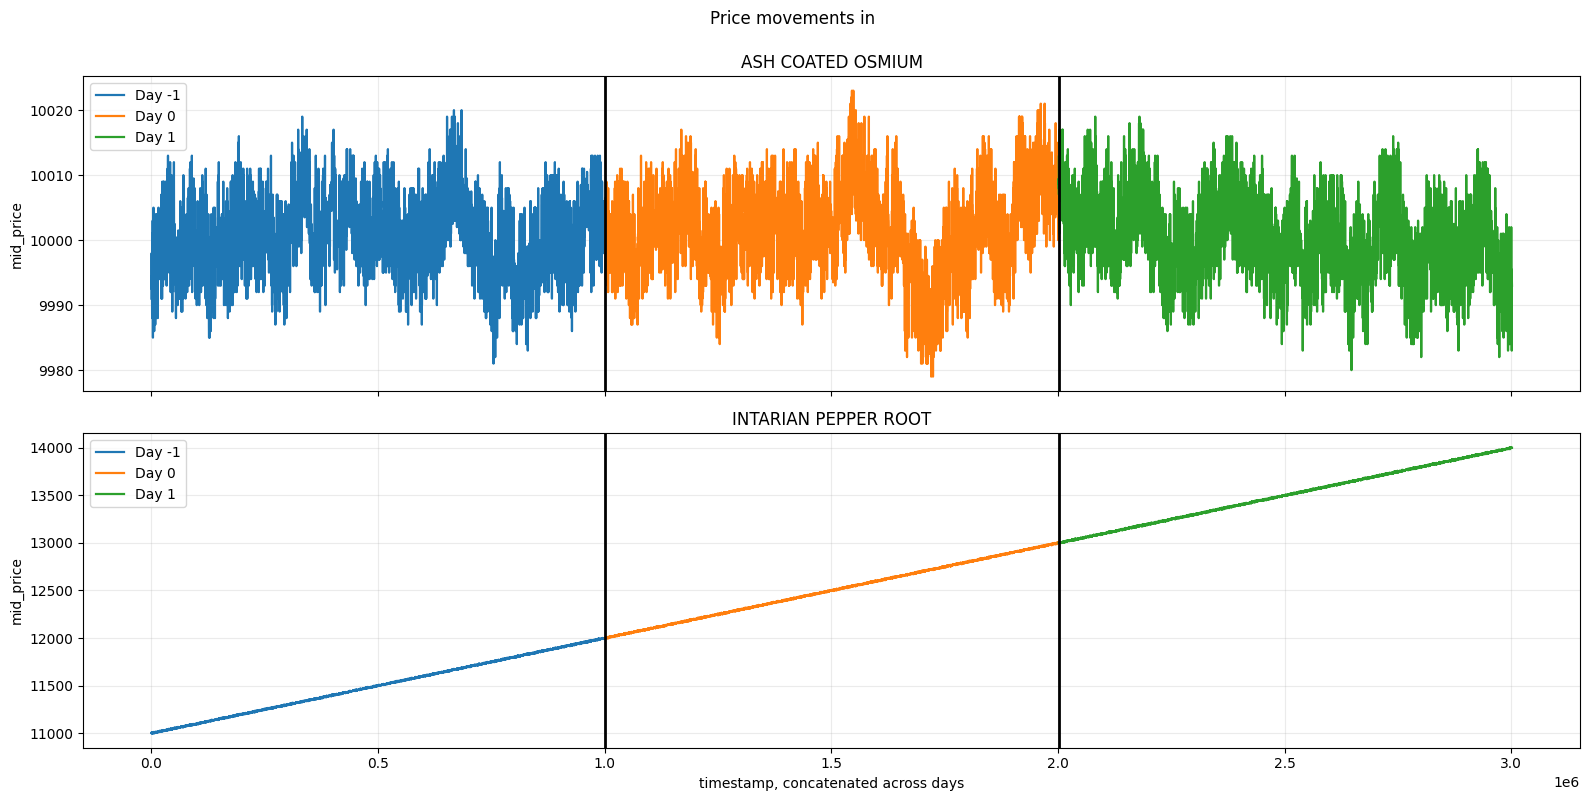

In [6]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import pandas as pd

ROUND_NUMBER = 2
ROUND_FOLDER = Path(".")

PRICE_FILES = sorted(ROUND_FOLDER.glob(f"prices_round_{ROUND_NUMBER}_day_*.csv"))
if not PRICE_FILES:
    raise FileNotFoundError(f"No price CSV files found in {ROUND_FOLDER}")

DAY_RE = re.compile(r"day_(-?\d+)\.csv$")
DAY_LABELS = []
frames = []
for file_path in PRICE_FILES:
    match = DAY_RE.search(file_path.name)
    if match is None:
        continue

    day = int(match.group(1))
    DAY_LABELS.append(day)

    df = pd.read_csv(file_path, sep=";")
    df["day"] = day
    df["timestamp"] = pd.to_numeric(df["timestamp"], errors="coerce")
    df["mid_price"] = pd.to_numeric(df["mid_price"], errors="coerce")
    frames.append(df[["day", "timestamp", "product", "mid_price"]])

if not frames:
    raise ValueError(f"No valid price data found in {ROUND_FOLDER}")

DAY_LABELS = sorted(set(DAY_LABELS))
prices = pd.concat(frames, ignore_index=True).dropna(subset=["timestamp", "mid_price"])
prices["timestamp"] = prices["timestamp"].astype(float)
plot_prices = prices.loc[prices["mid_price"] > 0].copy()
products = sorted(plot_prices["product"].dropna().unique())

# Build a continuous x-axis for the days and leave a visible gap between them.
gap = 1000.0
x_offsets = {}
separator_positions = []
current_offset = 0.0
for day in DAY_LABELS:
    day_prices = plot_prices[plot_prices["day"] == day]
    max_timestamp = float(day_prices["timestamp"].max()) if not day_prices.empty else 0.0
    x_offsets[day] = current_offset
    separator_positions.append(current_offset + max_timestamp + gap / 2)
    current_offset += max_timestamp + gap

fig, axes = plt.subplots(len(products), 1, figsize=(16, max(4, 4 * len(products))), sharex=True)
if len(products) == 1:
    axes = [axes]

cmap = plt.get_cmap("tab10")
color_map = {day: cmap(i % cmap.N) for i, day in enumerate(DAY_LABELS)}

for ax, product in zip(axes, products):
    product_prices = plot_prices[plot_prices["product"] == product].sort_values(["day", "timestamp"])

    for day in DAY_LABELS:
        day_prices = product_prices[product_prices["day"] == day].sort_values("timestamp")
        if day_prices.empty:
            continue

        x_values = day_prices["timestamp"] + x_offsets[day]
        ax.plot(
            x_values,
            day_prices["mid_price"],
            color=color_map[day],
            linewidth=1.6,
            label=f"Day {day}",
        )

    for separator in separator_positions[:-1]:
        ax.axvline(separator, color="black", linewidth=2)

    ax.set_title(product.replace("_", " "))
    ax.set_ylabel("mid_price")
    ax.grid(alpha=0.25)
    ax.legend(loc="best")
    ax.ticklabel_format(axis="y", style="plain", useOffset=False)

axes[-1].set_xlabel("timestamp, concatenated across days")
fig.suptitle(f"Price movements in {ROUND_FOLDER.name}", y=0.995)
fig.tight_layout()
plt.show()


In [7]:
product_name = "ASH_COATED_OSMIUM"
product_prices = prices.loc[
    (prices["product"] == product_name) & (prices["mid_price"] > 0),
    "mid_price",
].dropna()

if product_prices.empty:
    raise ValueError(f"No positive mid_price data found for {product_name}")

price_level_table = (
    product_prices.value_counts()
    .sort_index()
    .rename_axis("mid_price")
    .reset_index(name="count")
    .sort_values("mid_price")
    .reset_index(drop=True)
)

price_level_table

,mid_price,count
0,9979.0,2
1,9980.0,1
2,9981.0,7
3,9982.0,8
4,9982.5,1
...,...,...
76,10019.5,1
77,10020.0,5
78,10021.0,3
79,10022.0,1


In [8]:
from pathlib import Path

import numpy as np
import pandas as pd
import ipywidgets as widgets
from IPython.display import display

LEVELS = (1, 2, 3)


def _normalize_columns(df: pd.DataFrame) -> pd.DataFrame:
    df.columns = [str(c).strip().lower() for c in df.columns]
    return df


def resolve_data_path(path: str) -> Path:
    candidate = Path(path)
    if candidate.exists():
        return candidate

    notebook_dir = Path.cwd()
    for root in (notebook_dir, notebook_dir.parent):
        candidate = root / path
        if candidate.exists():
            return candidate

    raise FileNotFoundError(f"Could not find data file: {path}")


def load_prices(path: str) -> pd.DataFrame:
    file_path = resolve_data_path(path)

    # Robust parsing: first try semicolon (expected), then auto-detect fallback.
    df = pd.read_csv(file_path, sep=";", engine="python")
    if "product" not in [str(c).strip().lower() for c in df.columns]:
        df = pd.read_csv(file_path, sep=None, engine="python")

    df = _normalize_columns(df)

    if "product" not in df.columns:
        raise ValueError(
            "CSV parsing succeeded but required column 'product' is missing. "
            f"Detected columns: {list(df.columns)}"
        )

    numeric_cols = ["timestamp", "mid_price"]
    for level in LEVELS:
        numeric_cols.extend(
            [
                f"bid_price_{level}",
                f"bid_volume_{level}",
                f"ask_price_{level}",
                f"ask_volume_{level}",
            ]
        )

    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    df["product"] = df["product"].astype(str).str.strip().str.upper()
    return df


In [9]:
def run_price_levels_window_widget(
    prices_csv: str,
    product: str = "DRYLAND_FLAX",
    window_size: int = 50,
    trades_csv: str = "trades_round_0_day_-1.csv",
) -> None:
    """Interactive plot of CSV price levels with trade overlays."""
    if window_size <= 0:
        raise ValueError("window_size must be > 0")

    df = load_prices(prices_csv)
    asset = product.strip().upper()
    sub = df[df["product"] == asset].copy()

    if sub.empty:
        raise ValueError(f"No rows found for product={asset} in {prices_csv}")

    cols = [
        "timestamp",
        "mid_price",
        "bid_price_1", "bid_price_2", "bid_price_3",
        "ask_price_1", "ask_price_2", "ask_price_3",
    ]
    available_cols = [c for c in cols if c in sub.columns]

    for c in available_cols:
        sub[c] = pd.to_numeric(sub[c], errors="coerce")

    if "timestamp" not in sub.columns:
        raise ValueError("Missing required column: timestamp")

    sub = (
        sub[available_cols]
        .dropna(subset=["timestamp"])
        .sort_values("timestamp")
        .drop_duplicates(subset=["timestamp"], keep="last")
        .reset_index(drop=True)
    )

    if sub.empty:
        raise ValueError("No usable timestamp rows after cleaning.")

    def reconstruct_side_levels(frame: pd.DataFrame, side: str) -> pd.DataFrame:
        value_cols = [
            col
            for col in [f"{side}_price_1", f"{side}_price_2", f"{side}_price_3"]
            if col in frame.columns
        ]

        far_values: list[float | None] = []
        mid_values: list[float | None] = []
        far_state: float | None = None
        mid_state: float | None = None

        for _, row in frame.iterrows():
            values = []
            for col in value_cols:
                value = pd.to_numeric(row[col], errors="coerce")
                if pd.notna(value) and value > 0:
                    values.append(float(value))

            values.sort()

            far_value = far_state
            mid_value = mid_state

            # Check if any values exist
            if values:
                pair_found = False

                # If 2 values exist
                if side == "ask" and len(values) >= 2:
                    candidate_mid = values[-2]
                    candidate_far = values[-1]
                    # Values are far and mid (not 'near' mid) (Confusing naming in retrospect)
                    if candidate_far - candidate_mid <= 3:
                        far_value = candidate_far
                        mid_value = candidate_mid
                        pair_found = True
                elif side == "bid" and len(values) >= 2:
                    candidate_far = values[0]
                    candidate_mid = values[1]
                    if candidate_mid - candidate_far <= 3:
                        far_value = candidate_far
                        mid_value = candidate_mid
                        pair_found = True

                # If 
                if not pair_found:
                    candidate = values[-1] if side == "ask" else values[0]

                    if far_state is None or mid_state is None:
                        far_value = candidate
                        mid_value = candidate
                    elif abs(candidate - far_state) <= 1:
                        far_value = candidate
                    elif abs(candidate - mid_state) <= 1:
                        mid_value = candidate

            far_state = far_value
            mid_state = mid_value
            far_values.append(far_value)
            mid_values.append(mid_value)

        return pd.DataFrame({f"far_{side}": far_values, f"mid_{side}": mid_values})

    bid_levels = reconstruct_side_levels(sub, "bid")
    ask_levels = reconstruct_side_levels(sub, "ask")
    sub = pd.concat([sub, bid_levels, ask_levels], axis=1)
    sub["alt_mid_price"] = sub[["far_bid", "mid_bid", "far_ask", "mid_ask"]].mean(axis=1)

    trades_path = resolve_data_path(trades_csv)
    trades = pd.read_csv(trades_path, sep=";", engine="python")
    if "price" not in [str(c).strip().lower() for c in trades.columns]:
        trades = pd.read_csv(trades_path, sep=None, engine="python")

    trades.columns = [str(c).strip().lower() for c in trades.columns]
    required_trade_cols = {"timestamp", "symbol", "price"}
    missing_trade_cols = required_trade_cols - set(trades.columns)
    if missing_trade_cols:
        raise ValueError(f"Missing required columns in trades CSV: {sorted(missing_trade_cols)}")

    trades["symbol"] = trades["symbol"].astype(str).str.strip().str.upper()
    trades["timestamp"] = pd.to_numeric(trades["timestamp"], errors="coerce")
    trades["price"] = pd.to_numeric(trades["price"], errors="coerce")
    trades = trades.dropna(subset=["timestamp", "price"])
    trades = trades[trades["symbol"] == asset].copy()

    n = len(sub)
    max_start = 0 if n <= window_size else n - window_size

    def plot_window(start_idx: int) -> None:
        start = int(start_idx)
        end = min(start + window_size, n)
        w = sub.iloc[start:end]

        plt.figure(figsize=(13, 5))

        if "alt_mid_price" in w.columns and w["alt_mid_price"].notna().any():
            plt.plot(w["timestamp"], w["alt_mid_price"], color="black", linewidth=2.1, label="alt_mid_price")

        if "far_bid" in w.columns and w["far_bid"].notna().any():
            plt.plot(w["timestamp"], w["far_bid"], color="#1B5E20", linewidth=1.8, linestyle="--", label="far_bid")
        if "mid_bid" in w.columns and w["mid_bid"].notna().any():
            plt.plot(w["timestamp"], w["mid_bid"], color="#66BB6A", linewidth=1.8, linestyle="--", label="mid_bid")
        if "far_ask" in w.columns and w["far_ask"].notna().any():
            plt.plot(w["timestamp"], w["far_ask"], color="#7B0000", linewidth=1.8, linestyle="--", label="far_ask")
        if "mid_ask" in w.columns and w["mid_ask"].notna().any():
            plt.plot(w["timestamp"], w["mid_ask"], color="#EF5350", linewidth=1.8, linestyle="--", label="mid_ask")

        bid_colors = ["#A5D6A7", "#4CAF50", "#1B5E20"]
        if "bid_price_1" in w.columns and w["bid_price_1"].notna().any():
            b1 = w[w["bid_price_1"].notna()]
            plt.scatter(b1["timestamp"], b1["bid_price_1"], color=bid_colors[0], s=20, alpha=0.95, label="bid_price_1 (old)")
        if "bid_price_2" in w.columns and w["bid_price_2"].notna().any():
            b2 = w[w["bid_price_2"].notna()]
            plt.scatter(b2["timestamp"], b2["bid_price_2"], color=bid_colors[1], s=20, alpha=0.95, label="bid_price_2 (old)")
        if "bid_price_3" in w.columns and w["bid_price_3"].notna().any():
            b3 = w[w["bid_price_3"].notna()]
            plt.scatter(b3["timestamp"], b3["bid_price_3"], color=bid_colors[2], s=20, alpha=0.95, label="bid_price_3 (old)")

        ask_colors = ["#FF7F7F", "#D32F2F", "#7B0000"]
        if "ask_price_1" in w.columns and w["ask_price_1"].notna().any():
            a1 = w[w["ask_price_1"].notna()]
            plt.scatter(a1["timestamp"], a1["ask_price_1"], color=ask_colors[0], s=20, alpha=0.95, label="ask_price_1 (old)")
        if "ask_price_2" in w.columns and w["ask_price_2"].notna().any():
            a2 = w[w["ask_price_2"].notna()]
            plt.scatter(a2["timestamp"], a2["ask_price_2"], color=ask_colors[1], s=20, alpha=0.95, label="ask_price_2 (old)")
        if "ask_price_3" in w.columns and w["ask_price_3"].notna().any():
            a3 = w[w["ask_price_3"].notna()]
            plt.scatter(a3["timestamp"], a3["ask_price_3"], color=ask_colors[2], s=20, alpha=0.95, label="ask_price_3 (old)")

        t_min = w["timestamp"].min()
        t_max = w["timestamp"].max()
        tw = trades[(trades["timestamp"] >= t_min) & (trades["timestamp"] <= t_max)]
        if not tw.empty:
            plt.scatter(
                tw["timestamp"],
                tw["price"],
                marker="x",
                color="#EFB63A",
                s=72,
                linewidths=3.2,
                alpha=0.9,
                label=f"trades ({len(tw)})",
            )

        t0 = int(w["timestamp"].iloc[0])
        t1 = int(w["timestamp"].iloc[-1])
        plt.title(f"{asset} Price Levels | {prices_csv} | timestamps {t0} to {t1} (n={len(w)})")
        plt.xlabel("timestamp")
        plt.ylabel("price")
        plt.grid(alpha=0.2)
        plt.legend(ncol=2)
        plt.tight_layout()
        plt.show()

    slider = widgets.IntSlider(
        value=0,
        min=0,
        max=max_start,
        step=1,
        description="Start idx",
        continuous_update=True,
        layout=widgets.Layout(width="900px"),
    )

    play = widgets.Play(
        value=0,
        min=0,
        max=max_start,
        step=1,
        interval=120,
        description="Auto",
    )

    widgets.jslink((play, "value"), (slider, "value"))

    output = widgets.interactive_output(plot_window, {"start_idx": slider})
    controls = widgets.HBox([play, slider])
    display(controls, output)


run_price_levels_window_widget(
    "prices_round_2_day_-1.csv",
    product="ASH_COATED_OSMIUM",
    window_size=50,
    trades_csv="trades_round_2_day_-1.csv",
)


Output()

In [10]:
run_price_levels_window_widget(
    "prices_round_2_day_-1.csv",
    product="INTARIAN_PEPPER_ROOT",
    window_size=50,
    trades_csv="trades_round_2_day_-1.csv",
)

Output()

tick 12700 on day -1 has literally no data. mid_price is 0 and pnl is 0 but thats it

another note this order book is wayy different than previous prosperities.

Trend im noticing is that any of price 1 2 3 can seemingly not exist. The further bid/asks are close together basically always 2 or 3 apart, and the one closest to the mid can be really far out

Approaches:

1. Calculate new_mid_price that is the average of the furthest bid/asks. Note: not perfect bc random values are missing, mid price can jump

2. Calculate alt_mid_price that tries to average the 2 furthest bid/asks. This is done by seeing if they are within 3 of each other, then averaging the values that are. Then average the averages.

3. New insight Im seeing after typing the other 2: there are lines that can be seen, theres a 

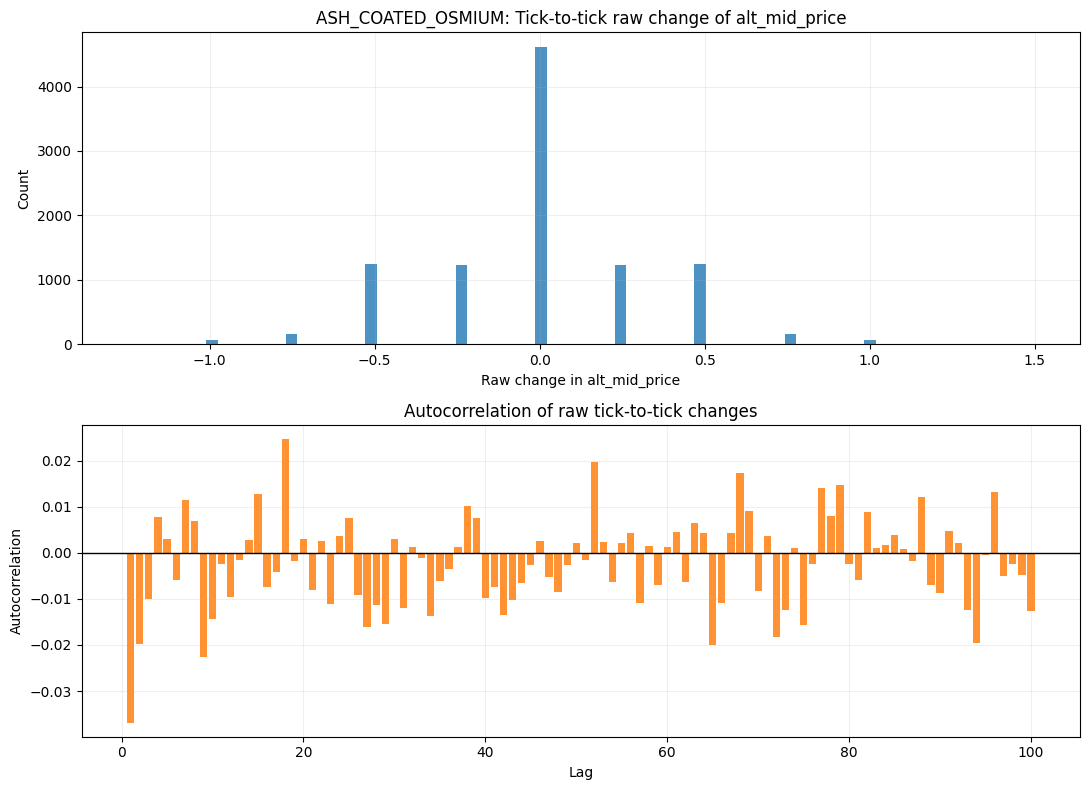

,raw_change
count,9998.000000
mean,0.000950
std,0.330635
min,-1.250000
1%,-0.750000
5%,-0.500000
50%,0.000000
95%,0.500000
99%,0.750000
max,1.500000


In [11]:
# Distribution of raw alt_mid_price changes from one tick to the next + autocorrelation.
asset = "ASH_COATED_OSMIUM"
prices_csv = "prices_round_2_day_-1.csv"

sub = load_prices(prices_csv)
sub = (
    sub[sub["product"] == asset]
    .dropna(subset=["timestamp"])
    .sort_values("timestamp")
    .drop_duplicates(subset=["timestamp"], keep="last")
    .reset_index(drop=True)
)

# Drop the very first tick before constructing alt_mid_price-derived diagnostics.
sub = sub.iloc[1:].reset_index(drop=True)


def reconstruct_side_levels(frame: pd.DataFrame, side: str) -> pd.DataFrame:
    value_cols = [
        col
        for col in [f"{side}_price_1", f"{side}_price_2", f"{side}_price_3"]
        if col in frame.columns
    ]

    far_values: list[float | None] = []
    mid_values: list[float | None] = []
    far_state: float | None = None
    mid_state: float | None = None

    for _, row in frame.iterrows():
        values = []
        for col in value_cols:
            value = pd.to_numeric(row[col], errors="coerce")
            if pd.notna(value) and value > 0:
                values.append(float(value))

        values.sort()

        far_value = far_state
        mid_value = mid_state

        if values:
            pair_found = False

            if side == "ask" and len(values) >= 2:
                candidate_mid = values[-2]
                candidate_far = values[-1]
                if candidate_far - candidate_mid <= 3:
                    far_value = candidate_far
                    mid_value = candidate_mid
                    pair_found = True
            elif side == "bid" and len(values) >= 2:
                candidate_far = values[0]
                candidate_mid = values[1]
                if candidate_mid - candidate_far <= 3:
                    far_value = candidate_far
                    mid_value = candidate_mid
                    pair_found = True

            if not pair_found:
                candidate = values[-1] if side == "ask" else values[0]

                if far_state is None or mid_state is None:
                    far_value = candidate
                    mid_value = candidate
                elif abs(candidate - far_state) <= 1:
                    far_value = candidate
                elif abs(candidate - mid_state) <= 1:
                    mid_value = candidate

        far_state = far_value
        mid_state = mid_value
        far_values.append(far_value)
        mid_values.append(mid_value)

    return pd.DataFrame({f"far_{side}": far_values, f"mid_{side}": mid_values})


bid_levels = reconstruct_side_levels(sub, "bid")
ask_levels = reconstruct_side_levels(sub, "ask")
sub = pd.concat([sub, bid_levels, ask_levels], axis=1)
sub["alt_mid_price"] = sub[["far_bid", "mid_bid", "far_ask", "mid_ask"]].mean(axis=1)

raw_change = sub["alt_mid_price"].diff().dropna()

fig, axes = plt.subplots(2, 1, figsize=(11, 8))

axes[0].hist(raw_change, bins=80, color="tab:blue", alpha=0.8)
axes[0].set_title(f"{asset}: Tick-to-tick raw change of alt_mid_price")
axes[0].set_xlabel("Raw change in alt_mid_price")
axes[0].set_ylabel("Count")
axes[0].grid(alpha=0.2)

max_lag = min(100, max(1, len(raw_change) // 5))
lags = list(range(1, max_lag + 1))
acf_vals = [raw_change.autocorr(lag=lag) for lag in lags]

axes[1].bar(lags, acf_vals, width=0.8, color="tab:orange", alpha=0.85)
axes[1].axhline(0.0, color="black", linewidth=1)
axes[1].set_title("Autocorrelation of raw tick-to-tick changes")
axes[1].set_xlabel("Lag")
axes[1].set_ylabel("Autocorrelation")
axes[1].grid(alpha=0.2)

fig.tight_layout()
plt.show()

display(raw_change.describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).to_frame(name="raw_change"))

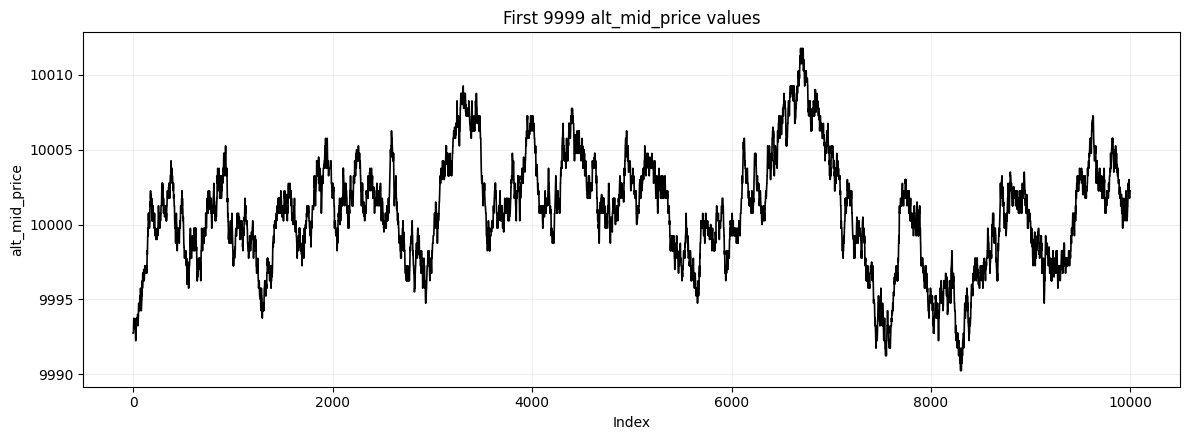

Plotted 9999 points out of 9999 available alt_mid_price values.


In [12]:
# Plot first 10,000 alt_mid_price values from the latest reconstructed series.
if "sub" not in globals() or "alt_mid_price" not in sub.columns:
    raise ValueError("Run Cell 7 first so 'sub' and 'alt_mid_price' are available.")

alt_series = sub["alt_mid_price"].dropna().reset_index(drop=True)
plot_n = min(10_000, len(alt_series))

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(range(plot_n), alt_series.iloc[:plot_n], color="black", linewidth=1.2)
ax.set_title(f"First {plot_n} alt_mid_price values")
ax.set_xlabel("Index")
ax.set_ylabel("alt_mid_price")
ax.grid(alpha=0.2)
fig.tight_layout()
plt.show()

print(f"Plotted {plot_n} points out of {len(alt_series)} available alt_mid_price values.")

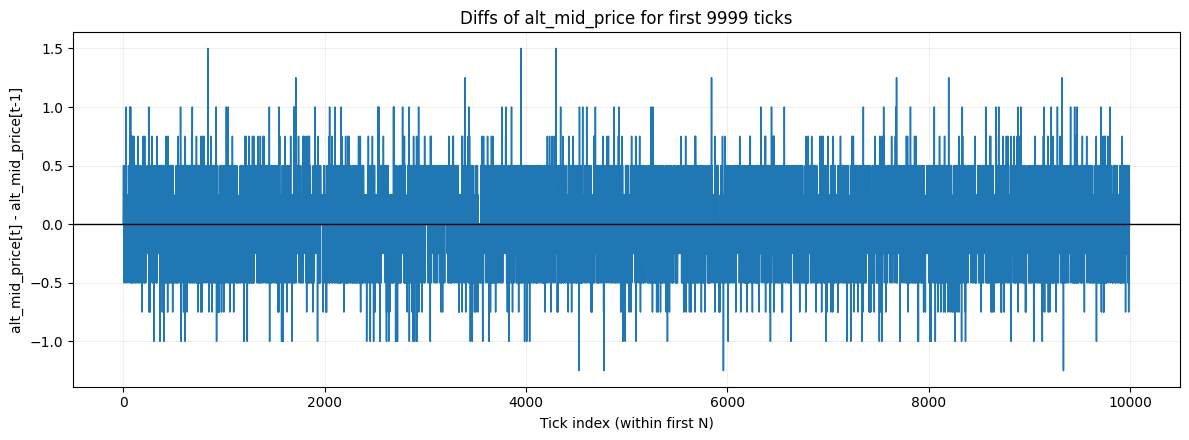

Used first 9999 ticks and plotted 9998 diffs.


In [13]:
# Plot diffs of alt_mid_price for the first 10,000 ticks.
if "sub" not in globals() or "alt_mid_price" not in sub.columns:
    raise ValueError("Run Cell 7 first so 'sub' and 'alt_mid_price' are available.")

alt_series = sub["alt_mid_price"].dropna().reset_index(drop=True)
plot_n = min(10_000, len(alt_series))

first_n = alt_series.iloc[:plot_n]
diffs = first_n.diff().dropna().reset_index(drop=True)

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(range(len(diffs)), diffs, color="tab:blue", linewidth=1.1)
ax.axhline(0.0, color="black", linewidth=1)
ax.set_title(f"Diffs of alt_mid_price for first {plot_n} ticks")
ax.set_xlabel("Tick index (within first N)")
ax.set_ylabel("alt_mid_price[t] - alt_mid_price[t-1]")
ax.grid(alpha=0.2)
fig.tight_layout()
plt.show()

print(f"Used first {plot_n} ticks and plotted {len(diffs)} diffs.")

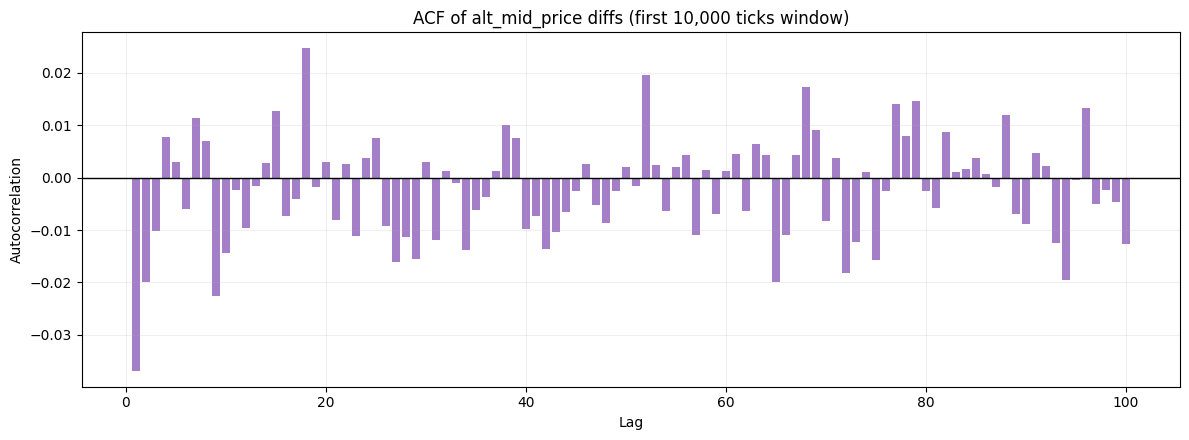

Computed ACF for lags 1..100 using 9998 diff points.


In [14]:
# ACF of diffs from the previous box.
if "diffs" not in globals():
    raise ValueError("Run the previous cell first so 'diffs' is available.")

if len(diffs) < 2:
    raise ValueError("Not enough diff values to compute autocorrelation.")

max_lag = min(100, max(1, len(diffs) // 5))
lags = list(range(1, max_lag + 1))
acf_vals = [diffs.autocorr(lag=lag) for lag in lags]

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.bar(lags, acf_vals, width=0.8, color="tab:purple", alpha=0.85)
ax.axhline(0.0, color="black", linewidth=1)
ax.set_title("ACF of alt_mid_price diffs (first 10,000 ticks window)")
ax.set_xlabel("Lag")
ax.set_ylabel("Autocorrelation")
ax.grid(alpha=0.2)
fig.tight_layout()
plt.show()

print(f"Computed ACF for lags 1..{max_lag} using {len(diffs)} diff points.")

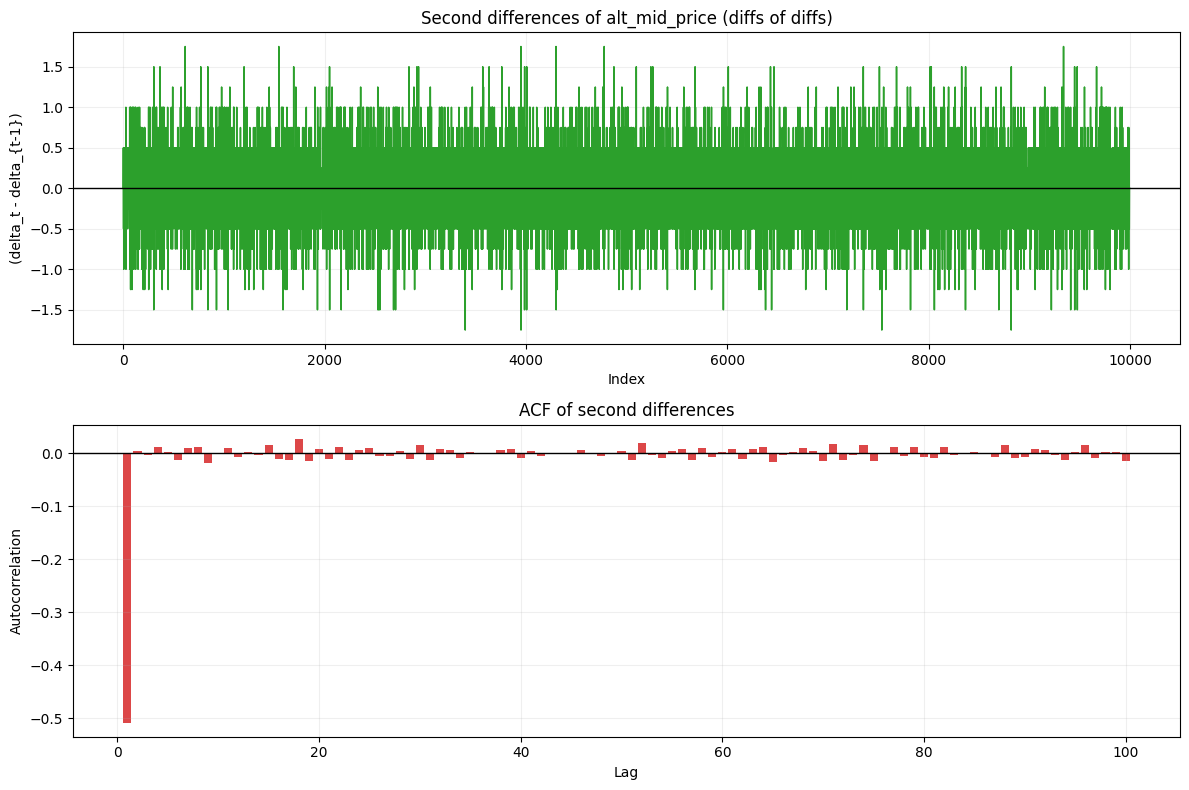

Computed second differences: 9997 points. ACF lags: 1..100.


In [15]:
# Plot second differences of alt_mid_price diffs, plus their autocorrelation.
if "diffs" not in globals():
    raise ValueError("Run the previous diff cell first so 'diffs' is available.")

diff_of_diffs = diffs.diff().dropna().reset_index(drop=True)
if len(diff_of_diffs) < 2:
    raise ValueError("Not enough second-difference points to plot autocorrelation.")

max_lag = min(100, max(1, len(diff_of_diffs) // 5))
lags = list(range(1, max_lag + 1))
acf_diff2 = [diff_of_diffs.autocorr(lag=lag) for lag in lags]

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

axes[0].plot(range(len(diff_of_diffs)), diff_of_diffs, color="tab:green", linewidth=1.1)
axes[0].axhline(0.0, color="black", linewidth=1)
axes[0].set_title("Second differences of alt_mid_price (diffs of diffs)")
axes[0].set_xlabel("Index")
axes[0].set_ylabel("(delta_t - delta_{t-1})")
axes[0].grid(alpha=0.2)

axes[1].bar(lags, acf_diff2, width=0.8, color="tab:red", alpha=0.85)
axes[1].axhline(0.0, color="black", linewidth=1)
axes[1].set_title("ACF of second differences")
axes[1].set_xlabel("Lag")
axes[1].set_ylabel("Autocorrelation")
axes[1].grid(alpha=0.2)

fig.tight_layout()
plt.show()

print(f"Computed second differences: {len(diff_of_diffs)} points. ACF lags: 1..{max_lag}.")

In [16]:
from pathlib import Path
from IPython.display import display
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import ipywidgets as widgets


PRODUCTS = ("INTARIAN_PEPPER_ROOT", "ASH_COATED_OSMIUM")
LEVELS = (1, 2, 3)


def resolve_data_path(path: str) -> Path:
    candidate = Path(path)
    if candidate.exists():
        return candidate

    search_roots = [
        Path.cwd(),
        Path.cwd().parent,
        Path.cwd() / "backtest" / "resources",
        Path.cwd().parent / "backtest" / "resources",
    ]
    for root in search_roots:
        test_path = (root / path).resolve()
        if test_path.exists():
            return test_path

    raise FileNotFoundError(f"Could not find CSV file: {path}")


def _normalize_columns(df: pd.DataFrame) -> pd.DataFrame:
    df.columns = [str(c).strip().lower() for c in df.columns]
    return df


def load_prices(path: str) -> pd.DataFrame:
    file_path = resolve_data_path(path)

    # Robust parsing: first try semicolon (expected), then auto-detect fallback.
    df = pd.read_csv(file_path, sep=";", engine="python")
    if "product" not in [str(c).strip().lower() for c in df.columns]:
        df = pd.read_csv(file_path, sep=None, engine="python")

    df = _normalize_columns(df)

    if "product" not in df.columns:
        raise ValueError(
            "CSV parsing succeeded but required column 'product' is missing. "
            f"Detected columns: {list(df.columns)}"
        )

    numeric_cols = ["timestamp", "mid_price"]
    for level in LEVELS:
        numeric_cols.extend(
            [
                f"bid_price_{level}",
                f"bid_volume_{level}",
                f"ask_price_{level}",
                f"ask_volume_{level}",
            ]
        )

    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    df["product"] = df["product"].astype(str).str.strip().str.upper()
    return df


def cumulative_depth(row: pd.Series, side: str) -> tuple[list[float], list[float]]:
    price_volume: dict[float, float] = {}

    for level in LEVELS:
        price = row.get(f"{side}_price_{level}")
        volume = row.get(f"{side}_volume_{level}")

        if pd.isna(price) or pd.isna(volume) or volume <= 0:
            continue

        price_value = float(price)
        volume_value = float(volume)
        price_volume[price_value] = price_volume.get(price_value, 0.0) + volume_value

    if not price_volume:
        return [], []

    reverse = side == "bid"
    prices = sorted(price_volume.keys(), reverse=reverse)

    cumulative = []
    running = 0.0
    for price in prices:
        running += price_volume[price]
        cumulative.append(running)

    return prices, cumulative


def draw_product_depth(ax: plt.Axes, row: pd.Series, product: str) -> None:
    ax.clear()

    bid_prices, bid_cum = cumulative_depth(row, "bid")
    ask_prices, ask_cum = cumulative_depth(row, "ask")

    if bid_prices:
        ax.step(bid_prices, bid_cum, where="post", color="tab:green", linewidth=2, label="Bids")
        ax.fill_between(bid_prices, bid_cum, step="post", alpha=0.25, color="tab:green")

    if ask_prices:
        ax.step(ask_prices, ask_cum, where="post", color="tab:red", linewidth=2, label="Asks")
        ax.fill_between(ask_prices, ask_cum, step="post", alpha=0.25, color="tab:red")

    mid_price = row.get("mid_price")
    if pd.notna(mid_price):
        ax.axvline(float(mid_price), linestyle="--", linewidth=1.5, color="tab:blue", label="Mid")

    best_bid = row.get("bid_price_1")
    best_ask = row.get("ask_price_1")
    spread_text = ""
    if pd.notna(best_bid) and pd.notna(best_ask):
        spread_text = f" | Spread: {float(best_ask) - float(best_bid):.2f}"

    ax.set_title(f"{product}{spread_text}")
    ax.set_xlabel("Price")
    ax.set_ylabel("Cumulative Volume")
    ax.grid(alpha=0.3)
    ax.legend(loc="upper left")


def run_visualizer(path: str = "prices_round_0_day_-1.csv") -> None:
    df = load_prices(path)

    filtered = df[df["product"].isin(PRODUCTS)].copy()
    if filtered.empty:
        raise ValueError("No rows found for EMERALDS or TOMATOES in the provided file.")

    timestamps = sorted(filtered["timestamp"].dropna().unique())
    if not timestamps:
        raise ValueError("No valid timestamp values found in the provided file.")

    data_by_product = {
        product: (
            filtered[filtered["product"] == product]
            .drop_duplicates(subset=["timestamp"], keep="last")
            .set_index("timestamp")
            .sort_index()
        )
        for product in PRODUCTS
    }

    def row_for_timestamp(product: str, timestamp: float) -> pd.Series | None:
        product_df = data_by_product[product]
        if timestamp not in product_df.index:
            return None
        return product_df.loc[timestamp]

    def plot_at_index(index: int) -> None:
        timestamp = timestamps[int(index)]

        fig = plt.figure(figsize=(14, 6))
        gs = gridspec.GridSpec(1, 2, width_ratios=[1, 1], wspace=0.25)
        ax_osmium = fig.add_subplot(gs[0, 0])
        ax_root = fig.add_subplot(gs[0, 1])
        # tomato = root, emerald = osmium i think

        osmium_row = row_for_timestamp("ASH_COATED_OSMIUM", timestamp)
        root_row = row_for_timestamp("INTARIAN_PEPPER_ROOT", timestamp)

        if osmium_row is not None:
            draw_product_depth(ax_osmium, osmium_row, "ASH_COATED_OSMIUM")
        else:
            ax_osmium.set_title("ASH_COATED_OSMIUM (no data)")

        if root_row is not None:
            draw_product_depth(ax_root, root_row, "INTARIAN_PEPPER_ROOT")
        else:
            ax_root.set_title("INTARIAN_PEPPER_ROOT (no data)")

        fig.suptitle(f"Order Book Depth | timestamp={int(timestamp)}", fontsize=14)
        plt.show()

    slider = widgets.IntSlider(
        min=0,
        max=len(timestamps) - 1,
        step=1,
        value=min(11, len(timestamps) - 1),
        description="Time idx",
        continuous_update=True,
        layout=widgets.Layout(width="850px"),
    )

    play = widgets.Play(
        value=slider.value,
        min=slider.min,
        max=slider.max,
        step=1,
        interval=100,  # 10 FPS
        description="Auto",
    )

    play_pause = widgets.ToggleButton(
        value=False,
        description="▶ Play",
        tooltip="Play/Pause at 10 FPS",
        layout=widgets.Layout(width="120px"),
    )

    widgets.jslink((play, "value"), (slider, "value"))

    def on_play_pause(change):
        is_playing = bool(change["new"])
        play_pause.description = "⏸ Pause" if is_playing else "▶ Play"
        if hasattr(play, "playing"):
            play.playing = is_playing
        else:
            play._playing = is_playing

    play_pause.observe(on_play_pause, names="value")

    out = widgets.interactive_output(plot_at_index, {"index": slider})
    controls = widgets.HBox([play_pause, play, slider])
    display(controls, out)

In [17]:
run_visualizer("prices_round_2_day_-1.csv")

Output()

In [18]:
trades = pd.read_csv(ROUND_FOLDER / "trades_round_2_day_1.csv", sep=';')
print(trades['symbol'].value_counts().sort_index())
trades = pd.read_csv(ROUND_FOLDER / "trades_round_2_day_0.csv", sep=';')
print(trades['symbol'].value_counts().sort_index())
trades = pd.read_csv(ROUND_FOLDER / "trades_round_2_day_-1.csv", sep=';')
print(trades['symbol'].value_counts().sort_index())

symbol
ASH_COATED_OSMIUM       465
INTARIAN_PEPPER_ROOT    333
Name: count, dtype: int64
symbol
ASH_COATED_OSMIUM       471
INTARIAN_PEPPER_ROOT    332
Name: count, dtype: int64
symbol
ASH_COATED_OSMIUM       459
INTARIAN_PEPPER_ROOT    331
Name: count, dtype: int64


Osmium has noticably more trades than root. ~4.2% of ticks vs ~3.3% of ticks

In [19]:
import re

get_day = lambda p: int(re.search(r"day_(-?\d+)", p.name).group(1))
trades = pd.concat((pd.read_csv(p, sep=';').assign(day=lambda d: d.get('day', get_day(p))) for p in ROUND_FOLDER.glob('trades_round_2_day_*.csv')), ignore_index=True)
prices = pd.concat((pd.read_csv(p, sep=';').assign(day=lambda d: d.get('day', get_day(p))) for p in ROUND_FOLDER.glob('prices_round_2_day_*.csv')), ignore_index=True)

trades = trades.rename(columns={'product': 'symbol'})
prices = prices.rename(columns={'product': 'symbol'})

x = trades.merge(prices[['day', 'timestamp', 'symbol', 'mid_price']], on=['day', 'timestamp', 'symbol'], how='left')
x['side'] = np.where(x['price'] > x['mid_price'], 'market_buy', np.where(x['price'] < x['mid_price'], 'market_sell', 'at_mid'))

x.groupby(['day', 'symbol', 'side']).size().unstack(fill_value=0).sort_index()

side                      at_mid  market_buy  market_sell
day symbol                                               
-1  ASH_COATED_OSMIUM         15         215          229
    INTARIAN_PEPPER_ROOT       9         171          151
 0  ASH_COATED_OSMIUM         21         221          229
    INTARIAN_PEPPER_ROOT      15         158          159
 1  ASH_COATED_OSMIUM         19         221          225
    INTARIAN_PEPPER_ROOT      11         157          165

Seemingly balanced buys/sells?


In [20]:
import math

# Use only trades that were clearly above/below mid
test_df = x[x['side'].isin(['market_buy', 'market_sell'])].copy()

# H0: P(market_buy) = P(market_sell) = 0.5
# For 2 categories, chi-square(df=1) p-value = erfc(sqrt(chi2/2))
def chi_equal_prob(group):
    buys = int((group['side'] == 'market_buy').sum())
    sells = int((group['side'] == 'market_sell').sum())
    n = buys + sells
    if n == 0:
        return pd.Series({'market_buy': 0, 'market_sell': 0, 'chi2': np.nan, 'p_value': np.nan})
    expected = n / 2
    chi2 = ((buys - expected) ** 2) / expected + ((sells - expected) ** 2) / expected
    p_value = math.erfc(math.sqrt(chi2 / 2))
    return pd.Series({'market_buy': buys, 'market_sell': sells, 'chi2': chi2, 'p_value': p_value})

overall_test = chi_equal_prob(test_df).to_frame().T
overall_test.index = ['overall']

by_day_asset_test = (
    test_df
    .groupby(['day', 'symbol'], as_index=True)
    .apply(chi_equal_prob)
    .sort_index()
)

print('Overall test (H0: buy and sell equally likely):')
display(overall_test)
print('By day and asset (small p-value => evidence against equal probabilities):')
display(by_day_asset_test)

Overall test (H0: buy and sell equally likely):


C:\Users\tolan\AppData\Local\Temp\ipykernel_1216\3311224420.py:25: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(chi_equal_prob)


,market_buy,market_sell,chi2,p_value
overall,1143.0,1158.0,0.097784,0.754506


By day and asset (small p-value => evidence against equal probabilities):


market_buy  market_sell      chi2   p_value
day symbol                                                           
-1  ASH_COATED_OSMIUM          215.0        229.0  0.441441  0.506428
    INTARIAN_PEPPER_ROOT       171.0        151.0  1.242236  0.265041
 0  ASH_COATED_OSMIUM          221.0        229.0  0.142222  0.706082
    INTARIAN_PEPPER_ROOT       158.0        159.0  0.003155  0.955210
 1  ASH_COATED_OSMIUM          221.0        225.0  0.035874  0.849775
    INTARIAN_PEPPER_ROOT       157.0        165.0  0.198758  0.655725

Yeah seems basically 50/50 buy/sell for market orders

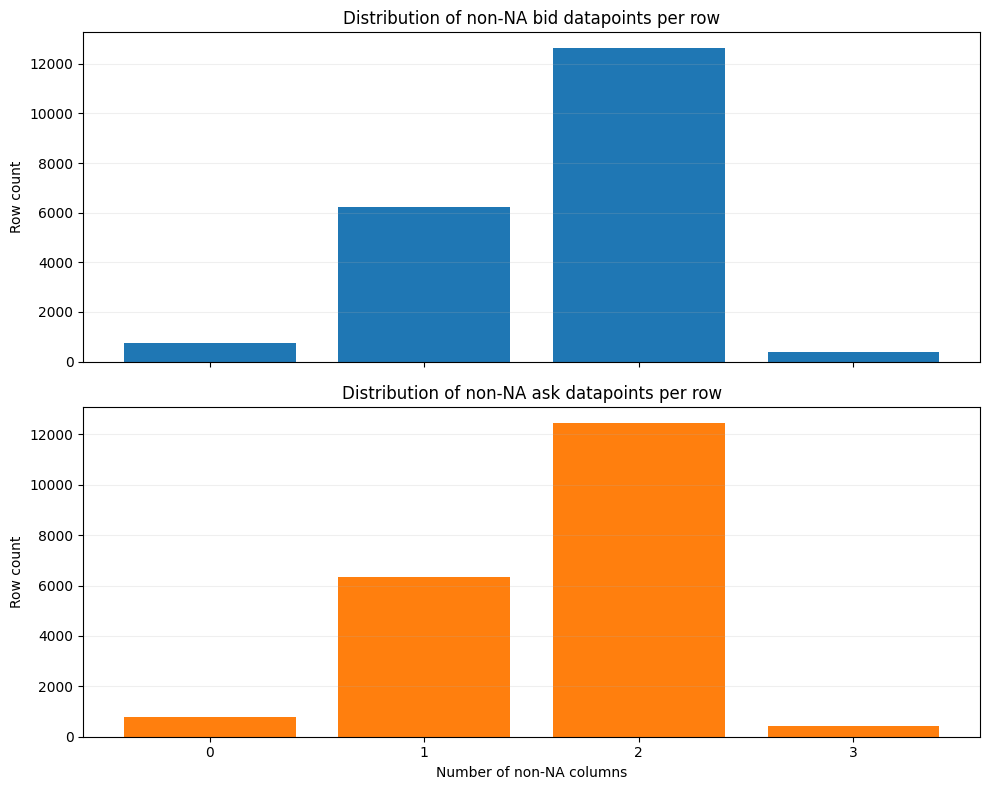

Bid columns: ['bid_price_1', 'bid_price_2', 'bid_price_3']
Ask columns: ['ask_price_1', 'ask_price_2', 'ask_price_3']
Bid count value counts:
 0      759
1     6223
2    12633
3      385
Name: count, dtype: int64
Ask count value counts:
 0      786
1     6357
2    12449
3      408
Name: count, dtype: int64


In [21]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

price_path = Path("prices_round_2_day_-1.csv")
price_df = pd.read_csv(price_path, sep=";")

bid_cols = [col for col in price_df.columns if col.startswith("bid_price")]
ask_cols = [col for col in price_df.columns if col.startswith("ask_price")]

bid_counts = price_df[bid_cols].notna().sum(axis=1)
ask_counts = price_df[ask_cols].notna().sum(axis=1)

bid_dist = bid_counts.value_counts().sort_index()
ask_dist = ask_counts.value_counts().sort_index()

fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

axes[0].bar(bid_dist.index, bid_dist.values, width=0.8, color="tab:blue")
axes[0].set_title("Distribution of non-NA bid datapoints per row")
axes[0].set_ylabel("Row count")
axes[0].grid(alpha=0.2, axis="y")

axes[1].bar(ask_dist.index, ask_dist.values, width=0.8, color="tab:orange")
axes[1].set_title("Distribution of non-NA ask datapoints per row")
axes[1].set_xlabel("Number of non-NA columns")
axes[1].set_ylabel("Row count")
axes[1].grid(alpha=0.2, axis="y")

max_count = int(max(bid_counts.max(), ask_counts.max()))
axes[1].set_xticks(range(0, max_count + 1))

fig.tight_layout()
plt.show()

print("Bid columns:", bid_cols)
print("Ask columns:", ask_cols)
print("Bid count value counts:\n", bid_dist)
print("Ask count value counts:\n", ask_dist)

In [22]:
import matplotlib.pyplot as plt
import pandas as pd


def plot_lowest_ask_highest_bid_distribution(
    csv_name: str,
    product: str,
    reference_x: float = 10000,
    figsize: tuple[int, int] = (12, 8),
) -> tuple[plt.Figure, list[plt.Axes]]:
    """Plot the distributions of the lowest ask and highest bid values for a product."""
    df = pd.read_csv(csv_name, sep=";")

    df.columns = [str(col).strip() for col in df.columns]
    if "product" not in df.columns:
        raise ValueError("Expected a 'product' column in the provided data.")

    product_df = df[df["product"] == product].copy()
    if product_df.empty:
        raise ValueError(f"No rows found for product={product}")

    ask_col = "ask_price_1"
    bid_col = "bid_price_1"
    missing_cols = [col for col in [ask_col, bid_col] if col not in product_df.columns]
    if missing_cols:
        raise ValueError(f"Missing required columns: {missing_cols}")

    lowest_ask = pd.to_numeric(product_df[ask_col], errors="coerce").dropna()
    highest_bid = pd.to_numeric(product_df[bid_col], errors="coerce").dropna()

    ask_dist = lowest_ask.value_counts().sort_index()
    bid_dist = highest_bid.value_counts().sort_index()

    x_min = float(min(ask_dist.index.min(), bid_dist.index.min()))
    x_max = float(max(ask_dist.index.max(), bid_dist.index.max()))

    fig, axes = plt.subplots(2, 1, figsize=figsize, sharex=True)

    axes[0].bar(ask_dist.index, ask_dist.values, width=1.0, color="tab:orange")
    axes[0].axvline(reference_x, color="black", linestyle="--", linewidth=1.8)
    axes[0].set_title(f"{product}: Distribution of Lowest Ask Values")
    axes[0].set_ylabel("Tick count")
    axes[0].grid(alpha=0.2, axis="y")

    axes[1].bar(bid_dist.index, bid_dist.values, width=1.0, color="tab:blue")
    axes[1].axvline(reference_x, color="black", linestyle="--", linewidth=1.8)
    axes[1].set_title(f"{product}: Distribution of Highest Bid Values")
    axes[1].set_xlabel("Price")
    axes[1].set_ylabel("Tick count")
    axes[1].grid(alpha=0.2, axis="y")

    axes[1].set_xlim(x_min - 1, x_max + 1)
    fig.tight_layout()
    plt.show()

    return fig, axes


product = "ASH_COATED_OSMIUM"
plot_lowest_ask_highest_bid_distribution("prices_round_2_day_-2.csv", product, reference_x=10000)
plot_lowest_ask_highest_bid_distribution("prices_round_2_day_-1.csv", product, reference_x=10000)
plot_lowest_ask_highest_bid_distribution("prices_round_2_day_0.csv", product, reference_x=10000)


FileNotFoundError: [Errno 2] No such file or directory: 'prices_round_2_day_-2.csv'

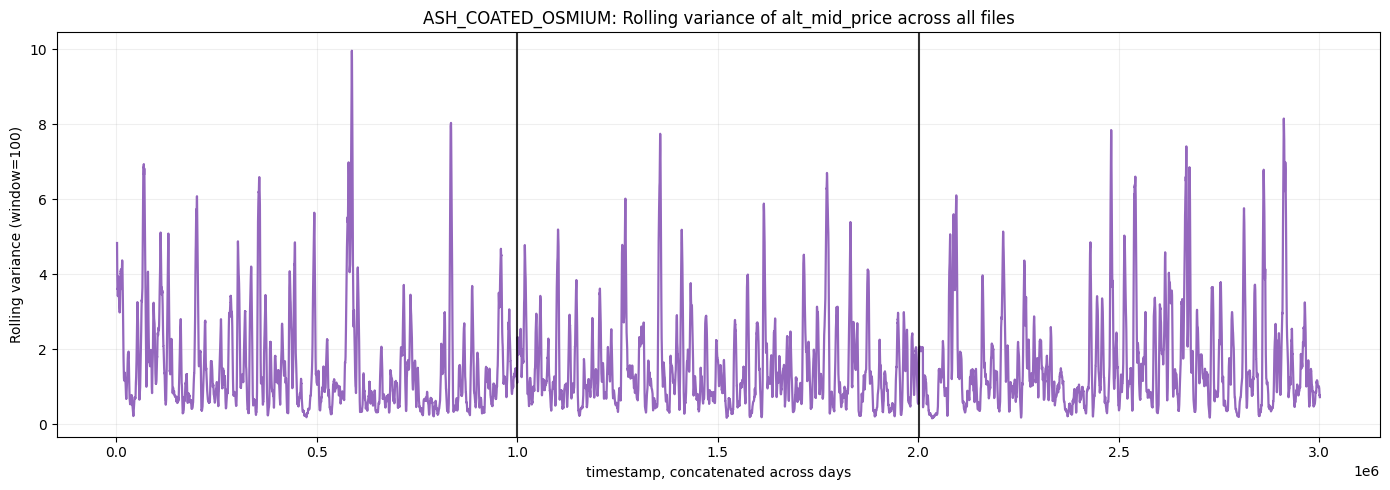

Overall alt_mid_price variance: 21.9634
Variance by day:


,day,variance
0,-2,20.635144
1,-1,13.067648
2,0,25.532628


(<Figure size 1400x500 with 1 Axes>,
 <Axes: title={'center': 'ASH_COATED_OSMIUM: Rolling variance of alt_mid_price across all files'}, xlabel='timestamp, concatenated across days', ylabel='Rolling variance (window=100)'>,
        day  timestamp          x  alt_mid_price  rolling_variance
 0       -2          0        0.0       10010.00               NaN
 1       -2        100      100.0       10000.75               NaN
 2       -2        200      200.0        9999.75               NaN
 3       -2        300      300.0        9999.75               NaN
 4       -2        400      400.0        9999.75               NaN
 ...    ...        ...        ...            ...               ...
 29995    0     999500  3001300.0       10007.50          0.775530
 29996    0     999600  3001400.0       10007.75          0.758561
 29997    0     999700  3001500.0       10007.75          0.741389
 29998    0     999800  3001600.0       10007.75          0.735253
 29999    0     999900  3001700.0       

In [ ]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def plot_alt_mid_price_variance(
    csv_names,
    product: str,
    window_size: int = 100,
    gap: float = 1000.0,
    figsize: tuple[int, int] = (14, 5),
):
    """Plot rolling variance of alt_mid_price across one or more price CSV files."""
    if isinstance(csv_names, str):
        csv_names = [csv_names]

    def reconstruct_side_levels(frame: pd.DataFrame, side: str) -> pd.DataFrame:
        value_cols = [
            col
            for col in [f"{side}_price_1", f"{side}_price_2", f"{side}_price_3"]
            if col in frame.columns
        ]

        far_values: list[float | None] = []
        mid_values: list[float | None] = []
        far_state: float | None = None
        mid_state: float | None = None

        for _, row in frame.iterrows():
            values = []
            for col in value_cols:
                value = pd.to_numeric(row[col], errors="coerce")
                if pd.notna(value) and value > 0:
                    values.append(float(value))

            values.sort()

            far_value = far_state
            mid_value = mid_state

            if values:
                pair_found = False

                if side == "ask" and len(values) >= 2:
                    candidate_mid = values[-2]
                    candidate_far = values[-1]
                    if candidate_far - candidate_mid <= 3:
                        far_value = candidate_far
                        mid_value = candidate_mid
                        pair_found = True
                elif side == "bid" and len(values) >= 2:
                    candidate_far = values[0]
                    candidate_mid = values[1]
                    if candidate_mid - candidate_far <= 3:
                        far_value = candidate_far
                        mid_value = candidate_mid
                        pair_found = True

                if not pair_found:
                    candidate = values[-1] if side == "ask" else values[0]

                    if far_state is None or mid_state is None:
                        far_value = candidate
                        mid_value = candidate
                    elif abs(candidate - far_state) <= 1:
                        far_value = candidate
                    elif abs(candidate - mid_state) <= 1:
                        mid_value = candidate

            far_state = far_value
            mid_state = mid_value
            far_values.append(far_value)
            mid_values.append(mid_value)

        return pd.DataFrame({f"far_{side}": far_values, f"mid_{side}": mid_values})

    frames = []
    day_markers = []
    current_offset = 0.0

    for csv_name in csv_names:
        day_match = re.search(r"day_(-?\d+)", Path(csv_name).name)
        day_label = int(day_match.group(1)) if day_match else None

        df = pd.read_csv(csv_name, sep=";")
        df.columns = [str(col).strip() for col in df.columns]
        if "product" not in df.columns:
            raise ValueError(f"Expected a 'product' column in {csv_name}")

        product_df = (
            df[df["product"] == product]
            .dropna(subset=["timestamp"])
            .sort_values("timestamp")
            .drop_duplicates(subset=["timestamp"], keep="last")
            .reset_index(drop=True)
        )

        if product_df.empty:
            continue

        missing_cols = [
            col
            for col in [
                "bid_price_1", "bid_price_2", "bid_price_3",
                "ask_price_1", "ask_price_2", "ask_price_3",
            ]
            if col not in product_df.columns
        ]
        if missing_cols:
            raise ValueError(f"Missing required columns in {csv_name}: {missing_cols}")

        bid_levels = reconstruct_side_levels(product_df, "bid")
        ask_levels = reconstruct_side_levels(product_df, "ask")
        product_df = pd.concat([product_df, bid_levels, ask_levels], axis=1)
        product_df["alt_mid_price"] = product_df[["far_bid", "mid_bid", "far_ask", "mid_ask"]].mean(axis=1)

        product_df["x"] = pd.to_numeric(product_df["timestamp"], errors="coerce") + current_offset
        product_df["day"] = day_label
        frames.append(product_df[["day", "timestamp", "x", "alt_mid_price"]].copy())

        max_timestamp = float(product_df["timestamp"].max())
        day_markers.append(current_offset + max_timestamp + gap / 2)
        current_offset += max_timestamp + gap

    if not frames:
        raise ValueError(f"No rows found for product={product} in the provided CSV files.")

    combined = pd.concat(frames, ignore_index=True).sort_values(["x"]).reset_index(drop=True)
    combined["rolling_variance"] = combined["alt_mid_price"].rolling(
        window=window_size,
        min_periods=max(5, window_size // 5),
    ).var()

    overall_variance = float(combined["alt_mid_price"].var())
    variance_by_day = (
        combined.groupby("day", dropna=False)["alt_mid_price"]
        .var()
        .reset_index(name="variance")
        .sort_values("day")
    )

    fig, ax = plt.subplots(figsize=figsize)
    ax.plot(combined["x"], combined["rolling_variance"], color="tab:purple", linewidth=1.6)

    for marker in day_markers[:-1]:
        ax.axvline(marker, color="black", linewidth=1.5, alpha=0.8)

    ax.set_title(f"{product}: Rolling variance of alt_mid_price across all files")
    ax.set_xlabel("timestamp, concatenated across days")
    ax.set_ylabel(f"Rolling variance (window={window_size})")
    ax.grid(alpha=0.2)
    fig.tight_layout()
    plt.show()

    print(f"Overall alt_mid_price variance: {overall_variance:.4f}")
    print("Variance by day:")
    display(variance_by_day)

    return fig, ax, combined, variance_by_day


plot_alt_mid_price_variance(
    [
        "prices_round_2_day_-1.csv",
        "prices_round_2_day_0.csv",
        "prices_round_2_day_1.csv",
    ],
    product="ASH_COATED_OSMIUM",
    window_size=100,
)



Ornstein-Uhlenbeck Model Fits for ASH_COATED_OSMIUM:


,day,theta,mu,sigma,mean,std,n_points
0,-1,0.008781,10000.966929,0.469350,10000.847475,3.613934,10000
1,0,0.004014,10001.757954,0.455971,10001.633975,5.050034,10000
2,1,0.006421,9999.969057,0.482518,10000.205850,4.276741,10000


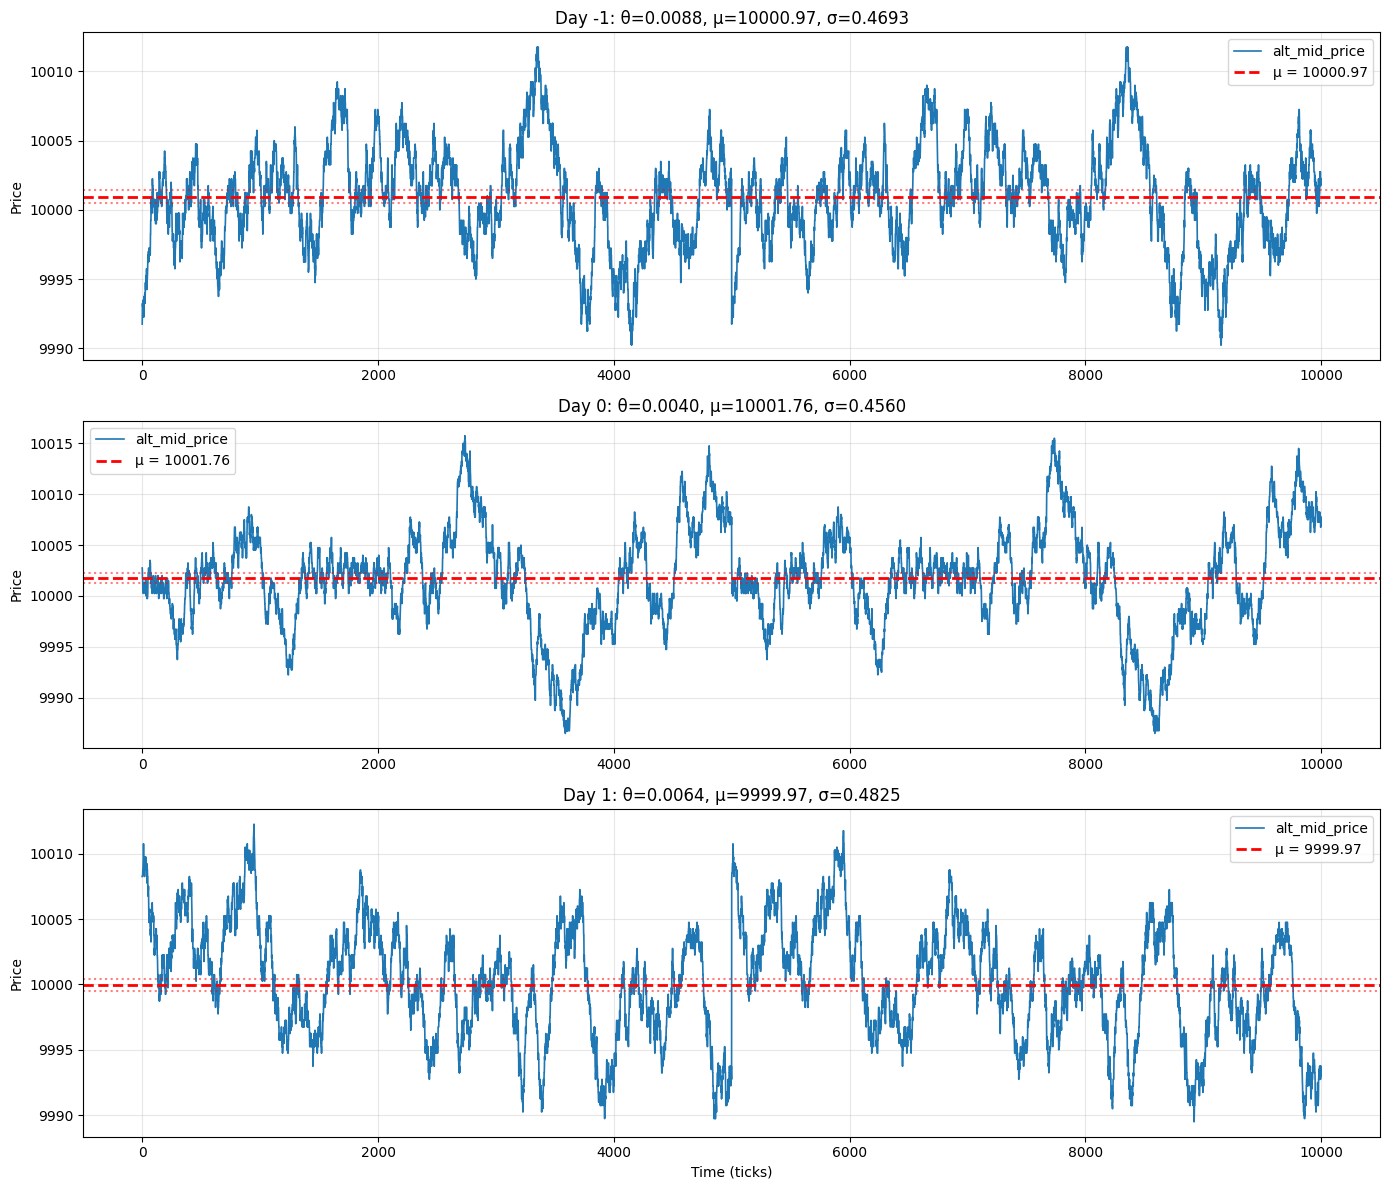

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from pathlib import Path
import re


def fit_ou_model(price_series: np.ndarray, dt: float = 1.0) -> dict:
    """
    Fit an Ornstein-Uhlenbeck model to a price series.
    
    The OU process: dX_t = θ(μ - X_t)dt + σ dW_t
    
    Args:
        price_series: Array of prices
        dt: Time step (default 1.0 assumes unit time intervals)
    
    Returns:
        Dictionary with parameters: theta (mean reversion speed), 
                                    mu (long-term mean),
                                    sigma (volatility)
    """
    if len(price_series) < 2:
        return None
    
    # Use linear regression on discretized OU form
    # Δx_t = (θ(μ - x_t)) * dt + σ * sqrt(dt) * dW_t
    # Δx_t = θ*μ*dt - θ*x_t*dt + σ*sqrt(dt)*dW_t
    
    x = price_series[:-1]  # X_t
    dx = np.diff(price_series)  # ΔX_t
    
    # Linear regression: dx = a + b*x
    # where a = θ*μ*dt and b = -θ*dt
    
    A = np.vstack([np.ones(len(x)), x]).T
    coeffs, _, _, _ = np.linalg.lstsq(A, dx, rcond=None)
    intercept, slope = coeffs
    
    # Recover parameters
    theta = -slope / dt  # mean reversion speed
    mu = intercept / (theta * dt) if abs(theta) > 1e-6 else np.mean(price_series)
    
    # Estimate volatility from residuals
    fitted = intercept + slope * x
    residuals = dx - fitted
    sigma = np.sqrt(np.var(residuals) / dt)
    
    # Ensure theta is positive
    if theta < 0:
        theta = abs(theta)
    
    return {
        'theta': theta,
        'mu': mu,
        'sigma': sigma,
        'mean': np.mean(price_series),
        'std': np.std(price_series),
        'n_points': len(price_series)
    }


# Load price data from all days
csv_files = [
    "prices_round_2_day_-1.csv",
    "prices_round_2_day_0.csv",
    "prices_round_2_day_1.csv",
]

def reconstruct_side_levels(frame: pd.DataFrame, side: str) -> pd.DataFrame:
    value_cols = [
        col
        for col in [f"{side}_price_1", f"{side}_price_2", f"{side}_price_3"]
        if col in frame.columns
    ]

    far_values: list[float | None] = []
    mid_values: list[float | None] = []
    far_state: float | None = None
    mid_state: float | None = None

    for _, row in frame.iterrows():
        values = []
        for col in value_cols:
            value = pd.to_numeric(row[col], errors="coerce")
            if pd.notna(value) and value > 0:
                values.append(float(value))

        values.sort()
        far_value = far_state
        mid_value = mid_state

        if values:
            pair_found = False
            if side == "ask" and len(values) >= 2:
                candidate_mid = values[-2]
                candidate_far = values[-1]
                if candidate_far - candidate_mid <= 3:
                    far_value = candidate_far
                    mid_value = candidate_mid
                    pair_found = True
            elif side == "bid" and len(values) >= 2:
                candidate_far = values[0]
                candidate_mid = values[1]
                if candidate_mid - candidate_far <= 3:
                    far_value = candidate_far
                    mid_value = candidate_mid
                    pair_found = True

            if not pair_found:
                candidate = values[-1] if side == "ask" else values[0]
                if far_state is None or mid_state is None:
                    far_value = candidate
                    mid_value = candidate
                elif abs(candidate - far_state) <= 1:
                    far_value = candidate
                elif abs(candidate - mid_state) <= 1:
                    mid_value = candidate

        far_state = far_value
        mid_state = mid_value
        far_values.append(far_value)
        mid_values.append(mid_value)

    return pd.DataFrame({f"far_{side}": far_values, f"mid_{side}": mid_values})


# Fit OU models for each day
results = []
product = "ASH_COATED_OSMIUM"

for csv_file in csv_files:
    day_match = re.search(r"day_(-?\d+)", csv_file)
    day = int(day_match.group(1)) if day_match else None
    
    df = pd.read_csv(csv_file, sep=";")
    product_df = df[df["product"] == product].copy()
    
    if product_df.empty:
        print(f"No data for {product} in {csv_file}")
        continue
    
    # Reconstruct price levels
    bid_levels = reconstruct_side_levels(product_df, "bid")
    ask_levels = reconstruct_side_levels(product_df, "ask")
    product_df = pd.concat([product_df, bid_levels, ask_levels], axis=1)
    
    # Compute alt_mid_price
    product_df["alt_mid_price"] = product_df[["far_bid", "mid_bid", "far_ask", "mid_ask"]].mean(axis=1)
    alt_prices = product_df["alt_mid_price"].dropna().values
    
    if len(alt_prices) < 2:
        print(f"Insufficient data for {product} in {csv_file}")
        continue
    
    # Fit OU model
    params = fit_ou_model(alt_prices)
    params['day'] = day
    params['file'] = csv_file
    results.append(params)

# Display results
results_df = pd.DataFrame(results)
print(f"\nOrnstein-Uhlenbeck Model Fits for {product}:")
print("=" * 80)
display(results_df[['day', 'theta', 'mu', 'sigma', 'mean', 'std', 'n_points']])

# Plot alt_mid_price with mean reversion levels for each day
fig, axes = plt.subplots(len(results), 1, figsize=(14, 4*len(results)))
if len(results) == 1:
    axes = [axes]

for ax, (idx, row) in zip(axes, results_df.iterrows()):
    csv_file = row['file']
    day = row['day']
    theta = row['theta']
    mu = row['mu']
    
    df = pd.read_csv(csv_file, sep=";")
    product_df = df[df["product"] == product].copy()
    
    bid_levels = reconstruct_side_levels(product_df, "bid")
    ask_levels = reconstruct_side_levels(product_df, "ask")
    product_df = pd.concat([product_df, bid_levels, ask_levels], axis=1)
    product_df["alt_mid_price"] = product_df[["far_bid", "mid_bid", "far_ask", "mid_ask"]].mean(axis=1)
    
    alt_prices = product_df["alt_mid_price"].dropna()
    
    ax.plot(alt_prices.values, linewidth=1.2, label='alt_mid_price', color='tab:blue')
    ax.axhline(mu, color='red', linestyle='--', linewidth=2, label=f'μ = {mu:.2f}')
    
    # Plot ±1σ bands around mean
    ax.axhline(mu + row['sigma'], color='red', linestyle=':', alpha=0.5)
    ax.axhline(mu - row['sigma'], color='red', linestyle=':', alpha=0.5)
    
    ax.set_title(f"Day {day}: θ={theta:.4f}, μ={mu:.2f}, σ={row['sigma']:.4f}")
    ax.set_ylabel('Price')
    ax.legend(loc='best')
    ax.grid(alpha=0.3)

axes[-1].set_xlabel('Time (ticks)')
fig.tight_layout()
plt.show()


JOINT MLE FIT (All days combined):


,theta,mu,sigma,mean,std,n_points_total,n_days
0,0.005748,10000.903279,0.4695,10000.895767,4.392309,30000,3



COMPARISON: Day-by-day average vs Joint MLE:


,Metric,Day-by-day Mean,Joint MLE
0,theta,0.006405,0.005748
1,mu,10000.897980,10000.903279
2,sigma,0.469279,0.469500


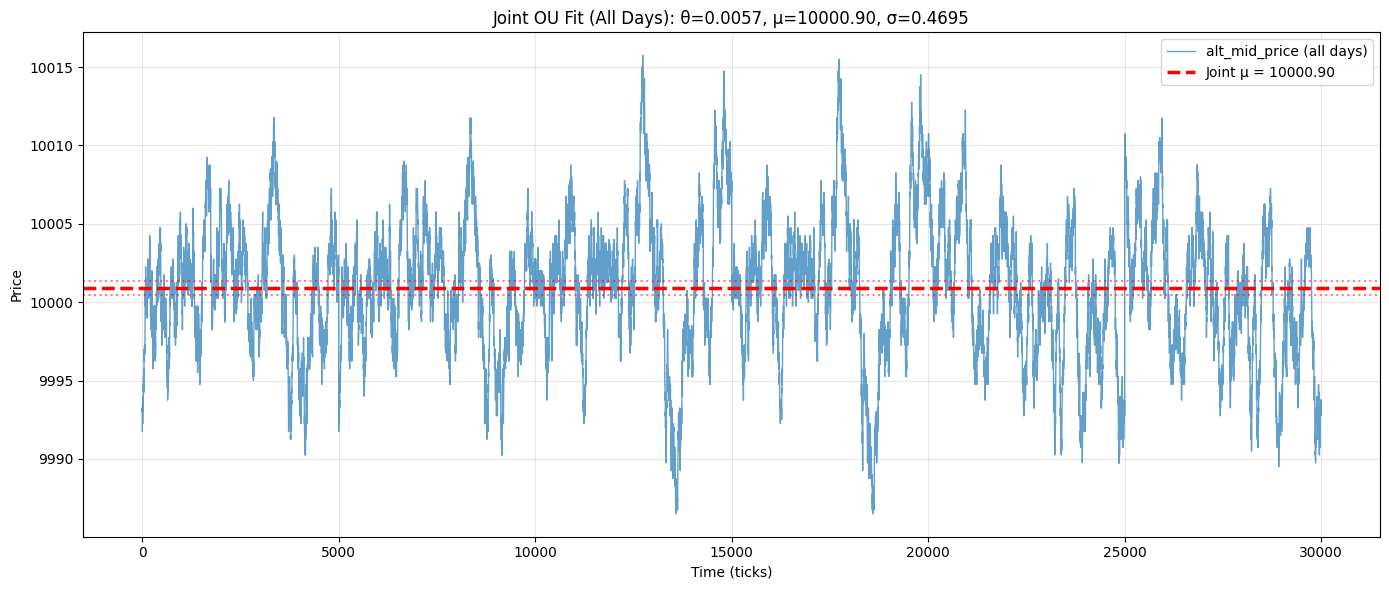


Recommended model parameters for trading:
  θ (mean reversion speed):  0.005748
  μ (long-term mean):        10000.9033
  σ (volatility):            0.469500


In [2]:
# Joint MLE: Fit single OU model to all days combined
all_price_arrays = []

for csv_file in csv_files:
    df = pd.read_csv(csv_file, sep=";")
    product_df = df[df["product"] == product].copy()
    
    bid_levels = reconstruct_side_levels(product_df, "bid")
    ask_levels = reconstruct_side_levels(product_df, "ask")
    product_df = pd.concat([product_df, bid_levels, ask_levels], axis=1)
    product_df["alt_mid_price"] = product_df[["far_bid", "mid_bid", "far_ask", "mid_ask"]].mean(axis=1)
    
    alt_prices = product_df["alt_mid_price"].dropna().values
    all_price_arrays.append(alt_prices)

# Concatenate all prices
all_combined_prices = np.concatenate(all_price_arrays)

# Fit joint OU model
joint_params = fit_ou_model(all_combined_prices)
joint_params['n_points_total'] = len(all_combined_prices)
joint_params['n_days'] = len(csv_files)

print("=" * 80)
print("JOINT MLE FIT (All days combined):")
print("=" * 80)
joint_summary = pd.DataFrame([joint_params])
display(joint_summary[['theta', 'mu', 'sigma', 'mean', 'std', 'n_points_total', 'n_days']])

# Compare single-day averages vs joint estimate
print("\n" + "=" * 80)
print("COMPARISON: Day-by-day average vs Joint MLE:")
print("=" * 80)
comparison = pd.DataFrame({
    'Metric': ['theta', 'mu', 'sigma'],
    'Day-by-day Mean': [
        results_df['theta'].mean(),
        results_df['mu'].mean(),
        results_df['sigma'].mean(),
    ],
    'Joint MLE': [
        joint_params['theta'],
        joint_params['mu'],
        joint_params['sigma'],
    ]
})
display(comparison)

# Plot: use joint parameters as reference
fig, ax = plt.subplots(figsize=(14, 6))

# Plot all combined prices
ax.plot(all_combined_prices[:min(30000, len(all_combined_prices))], linewidth=1.0, label='alt_mid_price (all days)', color='tab:blue', alpha=0.7)

# Add mean reversion lines
theta_j = joint_params['theta']
mu_j = joint_params['mu']
sigma_j = joint_params['sigma']

ax.axhline(mu_j, color='red', linestyle='--', linewidth=2.5, label=f'Joint μ = {mu_j:.2f}')
ax.axhline(mu_j + sigma_j, color='red', linestyle=':', alpha=0.5, linewidth=1.5)
ax.axhline(mu_j - sigma_j, color='red', linestyle=':', alpha=0.5, linewidth=1.5)

ax.set_title(f"Joint OU Fit (All Days): θ={theta_j:.4f}, μ={mu_j:.2f}, σ={sigma_j:.4f}")
ax.set_xlabel('Time (ticks)')
ax.set_ylabel('Price')
ax.legend(loc='best')
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

print(f"\nRecommended model parameters for trading:")
print(f"  θ (mean reversion speed):  {theta_j:.6f}")
print(f"  μ (long-term mean):        {mu_j:.4f}")
print(f"  σ (volatility):            {sigma_j:.6f}")


In [ ]:
# Constrained OU fit where μ is fixed at 10000
def fit_ou_model_constrained_mu(price_series: np.ndarray, mu_fixed: float, dt: float = 1.0) -> dict:
    """
    Fit OU model with fixed mean μ. 
    
    The OU process: dX_t = θ(μ - X_t)dt + σ dW_t
    With μ fixed, we only estimate θ and σ.
    
    Using linear regression: dx = -θ(x - μ)dt + σ√dt dW_t
    """
    if len(price_series) < 2:
        return None
    
    x = price_series[:-1]
    dx = np.diff(price_series)
    
    # Transform: dx = -θ * (x - μ_fixed) * dt + noise
    # Linear regression through origin (no intercept)
    x_centered = (x - mu_fixed)
    
    # Fit: dx = slope * x_centered
    # where slope = -θ*dt
    slope = np.dot(dx, x_centered) / np.dot(x_centered, x_centered)
    
    # Recover parameters
    theta = -slope / dt
    
    # Estimate volatility from residuals
    fitted = slope * x_centered
    residuals = dx - fitted
    sigma = np.sqrt(np.var(residuals) / dt)
    
    # Ensure theta is positive
    if theta < 0:
        theta = abs(theta)
    
    return {
        'theta': theta,
        'mu': mu_fixed,
        'sigma': sigma,
        'mean': np.mean(price_series),
        'std': np.std(price_series),
        'n_points': len(price_series),
        'mse_residuals': np.mean(residuals**2)
    }


# Fit constrained model
constrained_params = fit_ou_model_constrained_mu(all_combined_prices, mu_fixed=10000.0)
constrained_params['n_points_total'] = len(all_combined_prices)

print("=" * 80)
print("CONSTRAINED FIT (μ fixed at 10000):")
print("=" * 80)
constrained_summary = pd.DataFrame([constrained_params])
display(constrained_summary[['theta', 'mu', 'sigma', 'mean', 'std', 'n_points_total', 'mse_residuals']])

# Compare all three approaches
print("\n" + "=" * 80)
print("COMPARISON: Unconstrained vs Constrained (μ=10000):")
print("=" * 80)
comparison_all = pd.DataFrame({
    'Approach': [
        'Unconstrained (MLE)',
        'Constrained (μ=10000)',
    ],
    'θ': [
        joint_params['theta'],
        constrained_params['theta'],
    ],
    'μ': [
        joint_params['mu'],
        constrained_params['mu'],
    ],
    'σ': [
        joint_params['sigma'],
        constrained_params['sigma'],
    ],
    'MSE (residuals)': [
        np.mean((all_combined_prices[:-1] - joint_params['mu'])**2),
        constrained_params['mse_residuals'],
    ]
})
display(comparison_all)

print("\n" + "=" * 80)
print("KEY INSIGHT:")
print("=" * 80)
print(f"Unconstrained μ estimate: {joint_params['mu']:.4f}")
print(f"Known μ: 10000.0000")
print(f"Difference: {abs(joint_params['mu'] - 10000.0):.4f}")
print()
if abs(joint_params['mu'] - 10000.0) < 2.0:
    print("✓ The unconstrained estimate is VERY CLOSE to 10000.")
    print("✓ Using the constraint barely changes θ and σ.")
    print("✓ Recommendation: Use CONSTRAINED fit (μ=10000) for:")
    print("  - Cleaner, more stable parameters")
    print("  - Better stability in trading systems")
    print("  - Reduced overfitting")
else:
    print("⚠ The unconstrained μ deviates significantly from 10000.")
    print("⚠ Consider whether the constraint is truly valid.")


CONSTRAINED FIT (μ fixed at 10000):


,theta,mu,sigma,mean,std,n_points_total,mse_residuals
0,0.005517,10000.0,0.469501,10000.895767,4.392309,30000,0.220456



COMPARISON: Unconstrained vs Constrained (μ=10000):


,Approach,θ,μ,σ,MSE (residuals)
0,Unconstrained (MLE),0.005748,10000.903279,0.469500,19.290999
1,Constrained (μ=10000),0.005517,10000.000000,0.469501,0.220456



KEY INSIGHT:
Unconstrained μ estimate: 10000.9033
Known μ: 10000.0000
Difference: 0.9033

✓ The unconstrained estimate is VERY CLOSE to 10000.
✓ Using the constraint barely changes θ and σ.
✓ Recommendation: Use CONSTRAINED fit (μ=10000) for:
  - Cleaner, more stable parameters
  - Better stability in trading systems
  - Reduced overfitting
